<a href="https://colab.research.google.com/github/Shamil2007/Machine-Learning/blob/main/Credit_Score_ML_Prediction_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!curl -L -o credit-score-classification.zip https://www.kaggle.com/api/v1/datasets/download/parisrohan/credit-score-classification

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 9739k  100 9739k    0     0  20.1M      0 --:--:-- --:--:-- --:--:-- 20.1M


In [2]:
!unzip /content/credit-score-classification.zip

Archive:  /content/credit-score-classification.zip
  inflating: test.csv                
  inflating: train.csv               


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

/tmp/ipykernel_576/4028968266.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv("train.csv")


In [5]:
df = df_train.copy()
df

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [7]:
df = df.drop(["ID", "Customer_ID", "Name", "SSN", "Type_of_Loan"], axis=1)
df

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,January,23,Scientist,19114.12,1824.843333,3,4,3,4,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,February,23,Scientist,19114.12,NaN,3,4,3,4,-1,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,March,-500,Scientist,19114.12,NaN,3,4,3,4,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,April,23,Scientist,19114.12,NaN,3,4,3,4,5,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,May,23,Scientist,19114.12,1824.843333,3,4,3,4,6,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,April,25,Mechanic,39628.99,3359.415833,4,6,7,2,23,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,May,25,Mechanic,39628.99,3359.415833,4,6,7,2,18,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,June,25,Mechanic,39628.99,3359.415833,4,6,5729,2,27,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,July,25,Mechanic,39628.99,3359.415833,4,6,7,2,20,...,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


# Data Cleaning

## Age

In [8]:
df['Age'] = df["Age"].str.replace("_", "")

In [9]:
df["Age"] = df['Age'].astype(np.int32)

In [10]:
df["Age"].min(), df["Age"].max()

(-500, 8698)

In [11]:
df.loc[(df["Age"] >= 100) | (df["Age"] < 16), "Age"] = np.nan

## Occupation

In [12]:
df["Occupation"].value_counts()

,count
Occupation,
_______,7062
Lawyer,6575
Architect,6355
Engineer,6350
Scientist,6299
Mechanic,6291
Accountant,6271
Developer,6235
Media_Manager,6232


In [13]:
df["Occupation"] = df["Occupation"].replace("_______", None)

## Annual Income

In [14]:
df["Annual_Income"] = df["Annual_Income"].str.replace("_", "").astype(np.float64)

In [15]:
df["Annual_Income"].min(), df["Annual_Income"].max()

(7005.93, 24198062.0)

In [16]:
df.loc[1_000_000 < df["Annual_Income"], "Annual_Income"] = 1_000_000

## Num_Bank_Accounts

In [17]:
df["Num_Bank_Accounts"].min(), df["Num_Bank_Accounts"].max()

(-1, 1798)

In [18]:
df.loc[(df["Num_Bank_Accounts"] > 10) | (df["Num_Bank_Accounts"] < 0), "Num_Bank_Accounts"] = np.nan

## Num_Credit_Card           

In [19]:
df["Num_Credit_Card"].min(), df["Num_Credit_Card"].max()

(0, 1499)

In [20]:
df.loc[df["Num_Credit_Card"] > 10, "Num_Credit_Card"] = np.nan

## Num_of_Loan

In [21]:
df["Num_of_Loan"] = df["Num_of_Loan"].str.replace("_", "").astype(np.int32)

In [22]:
df["Num_of_Loan"].min(), df["Num_of_Loan"].max()

(-100, 1496)

In [23]:
df.loc[(df["Num_of_Loan"] > 10) | (df["Num_of_Loan"] < 0), "Num_of_Loan"] = np.nan

## Delay_from_due_date

In [24]:
df['Delay_from_due_date'].min(), df['Delay_from_due_date'].max()

(-5, 67)

In [25]:
df.loc[df['Delay_from_due_date'] < 0, 'Delay_from_due_date'] = np.nan

## Num_of_Delayed_Payment    

In [26]:
df["Num_of_Delayed_Payment"] = df["Num_of_Delayed_Payment"].str.replace("_", "").replace("", np.nan).astype(np.float32)

In [27]:
df["Num_of_Delayed_Payment"].min(), df["Num_of_Delayed_Payment"].max()

(-3.0, 4397.0)

In [28]:
df.loc[(0 > df["Num_of_Delayed_Payment"]) | (df["Num_of_Delayed_Payment"] > 30), "Num_of_Delayed_Payment"] = np.nan

## Interest_Rate

In [29]:
df["Interest_Rate"].min(), df["Interest_Rate"].max()

(1, 5797)

In [30]:
df.loc[df["Interest_Rate"] > 100, "Interest_Rate"] = np.nan

## Changed_Credit_Limit

In [31]:
df["Changed_Credit_Limit"] = df["Changed_Credit_Limit"].str.replace("_", "").replace('', np.nan).astype(np.float64)

In [32]:
df["Changed_Credit_Limit"].min(), df["Changed_Credit_Limit"].max()

(-6.49, 36.97)

In [33]:
df.loc[0 > df["Changed_Credit_Limit"], "Changed_Credit_Limit"] = np.nan

##Num_Credit_Inquiries

In [34]:
df.loc[df["Num_Credit_Inquiries"] > 20, "Num_Credit_Inquiries"] = np.nan

##Credit_Mix

In [35]:
df["Credit_Mix"].value_counts()

,count
Credit_Mix,
Standard,36479
Good,24337
_,20195
Bad,18989


In [36]:
df["Credit_Mix"] = df["Credit_Mix"].replace("_", None)

##Outstanding_Debt

In [37]:
df["Outstanding_Debt"] = df["Outstanding_Debt"].str.replace("_", "").astype(np.float64)

##Credit_History_Age

In [38]:
df["Credit_History_Age"].head()

,Credit_History_Age
0,22 Years and 1 Months
1,NaN
2,22 Years and 3 Months
3,22 Years and 4 Months
4,22 Years and 5 Months


In [39]:
years = df["Credit_History_Age"].str.extract(r'(\d+)\s*Years')[0].astype(np.float64)
months = df["Credit_History_Age"].str.extract(r'(\d+)\s*Months')[0].astype(np.float64)

In [40]:
df["Credit_History_Age_Months"] = (years * 12) + months

In [41]:
df.drop("Credit_History_Age", axis=1, inplace=True)

## Payment_of_Min_Amount

In [42]:
df["Payment_of_Min_Amount"].value_counts()

,count
Payment_of_Min_Amount,
Yes,52326
No,35667
NM,12007


In [43]:
df.loc[df['Payment_of_Min_Amount'] == 'NM', 'Payment_of_Min_Amount'] = None

## Total_EMI_per_month

In [44]:
df["Total_EMI_per_month"].min(), df["Total_EMI_per_month"].max()

(0.0, 82331.0)

In [45]:
df.loc[df['Total_EMI_per_month'] > 1_000, 'Total_EMI_per_month'] = 1_000

##Amount_invested_monthly

In [46]:
df["Amount_invested_monthly"] = df["Amount_invested_monthly"].str.replace("_", "").astype(np.float64)

In [47]:
df["Amount_invested_monthly"].min(), df["Amount_invested_monthly"].max()

(0.0, 10000.0)

In [48]:
df.loc[df["Amount_invested_monthly"] > df["Amount_invested_monthly"].quantile(0.95), "Amount_invested_monthly"] = df["Amount_invested_monthly"].quantile(0.95)

##Payment_Behaviour

In [49]:
df["Payment_Behaviour"].value_counts()

,count
Payment_Behaviour,
Low_spent_Small_value_payments,25513
High_spent_Medium_value_payments,17540
Low_spent_Medium_value_payments,13861
High_spent_Large_value_payments,13721
High_spent_Small_value_payments,11340
Low_spent_Large_value_payments,10425
!@9#%8,7600


In [50]:
df.loc[df['Payment_Behaviour'] == '!@9#%8', 'Payment_Behaviour'] = None

## Monthly_Balance

In [51]:
df["Monthly_Balance"] = df["Monthly_Balance"].str.replace("_", "").astype(np.float64)

In [52]:
df["Monthly_Balance"].min(), df["Monthly_Balance"].max()

(-3.333333333333333e+26, 1602.0405189622518)

In [53]:
df.loc[0 > df["Monthly_Balance"], "Monthly_Balance"] = None

##Credit Score

In [54]:
df.dropna(subset=['Credit_Score'], inplace=True)

# Data Analysis

##Numerical values

In [55]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months
count,94474.000000,100000.000000,84998.000000,98655.000000,97693.000000,97988.000000,95652.000000,99409.000000,91618.000000,96323.000000,96385.000000,100000.000000,100000.000000,100000.000000,95521.000000,97123.000000,90970.000000
mean,33.868175,59818.260678,4194.170850,5.368466,5.531307,14.546679,3.533758,21.207245,13.419634,10.599042,5.781117,1426.220376,32.285173,134.487498,237.614338,402.164483,221.195405
std,10.439596,100738.555040,3183.686167,2.592011,2.065418,8.798523,2.447308,14.794693,6.207201,6.639966,3.860712,1155.129026,5.116875,197.077324,274.239386,213.644217,99.741364
min,16.000000,7005.930000,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.230000,20.000000,0.000000,0.000000,0.007760,1.000000
25%,25.000000,19457.500000,1625.568229,3.000000,4.000000,7.000000,2.000000,10.000000,9.000000,5.570000,3.000000,566.072500,28.052567,30.306660,74.534002,269.998334,144.000000
50%,34.000000,37578.610000,3093.745000,5.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.520000,5.000000,1166.155000,32.305784,69.249473,135.925682,336.472111,219.000000
75%,42.000000,72790.920000,5957.448333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,15.010000,8.000000,1945.962500,36.496663,161.224249,265.731733,469.652004,302.000000
max,99.000000,1000000.000000,15204.633333,10.000000,10.000000,100.000000,9.000000,67.000000,28.000000,36.970000,17.000000,4998.070000,50.000000,1000.000000,1149.405785,1602.040519,404.000000


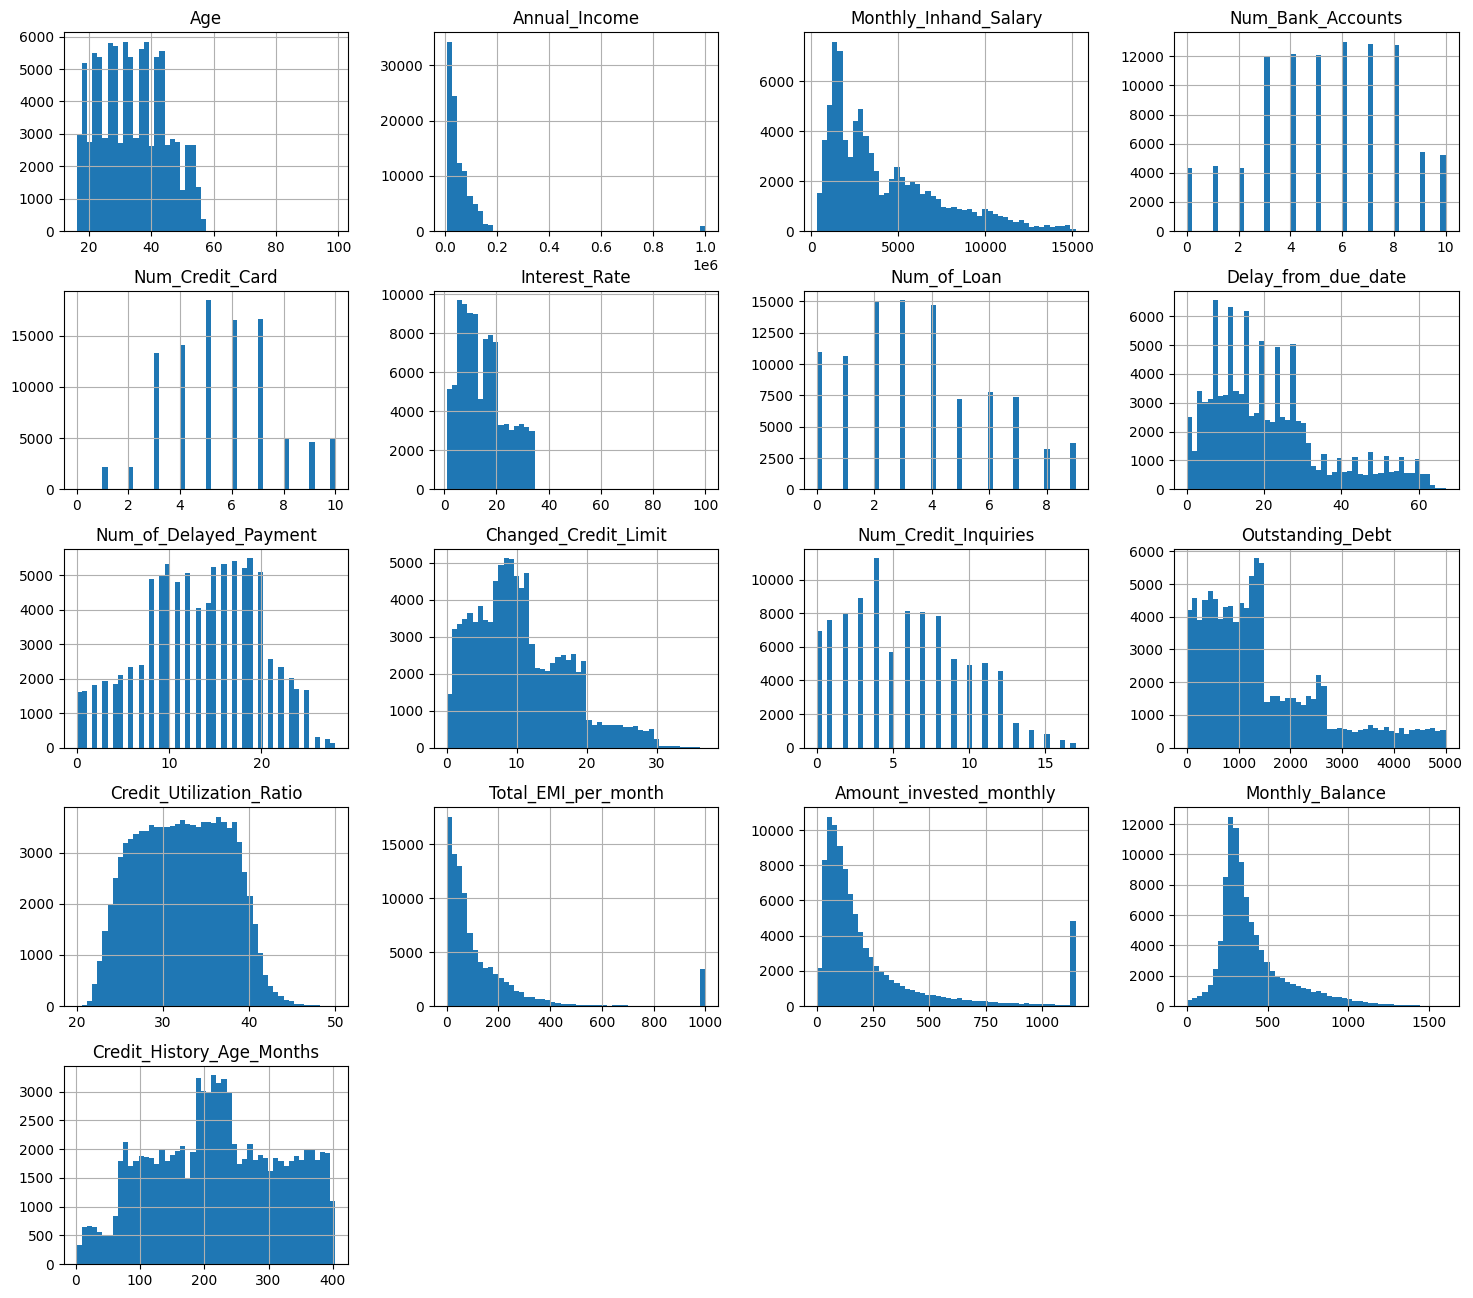

In [56]:
df.hist(bins=50, figsize=(18, 16));

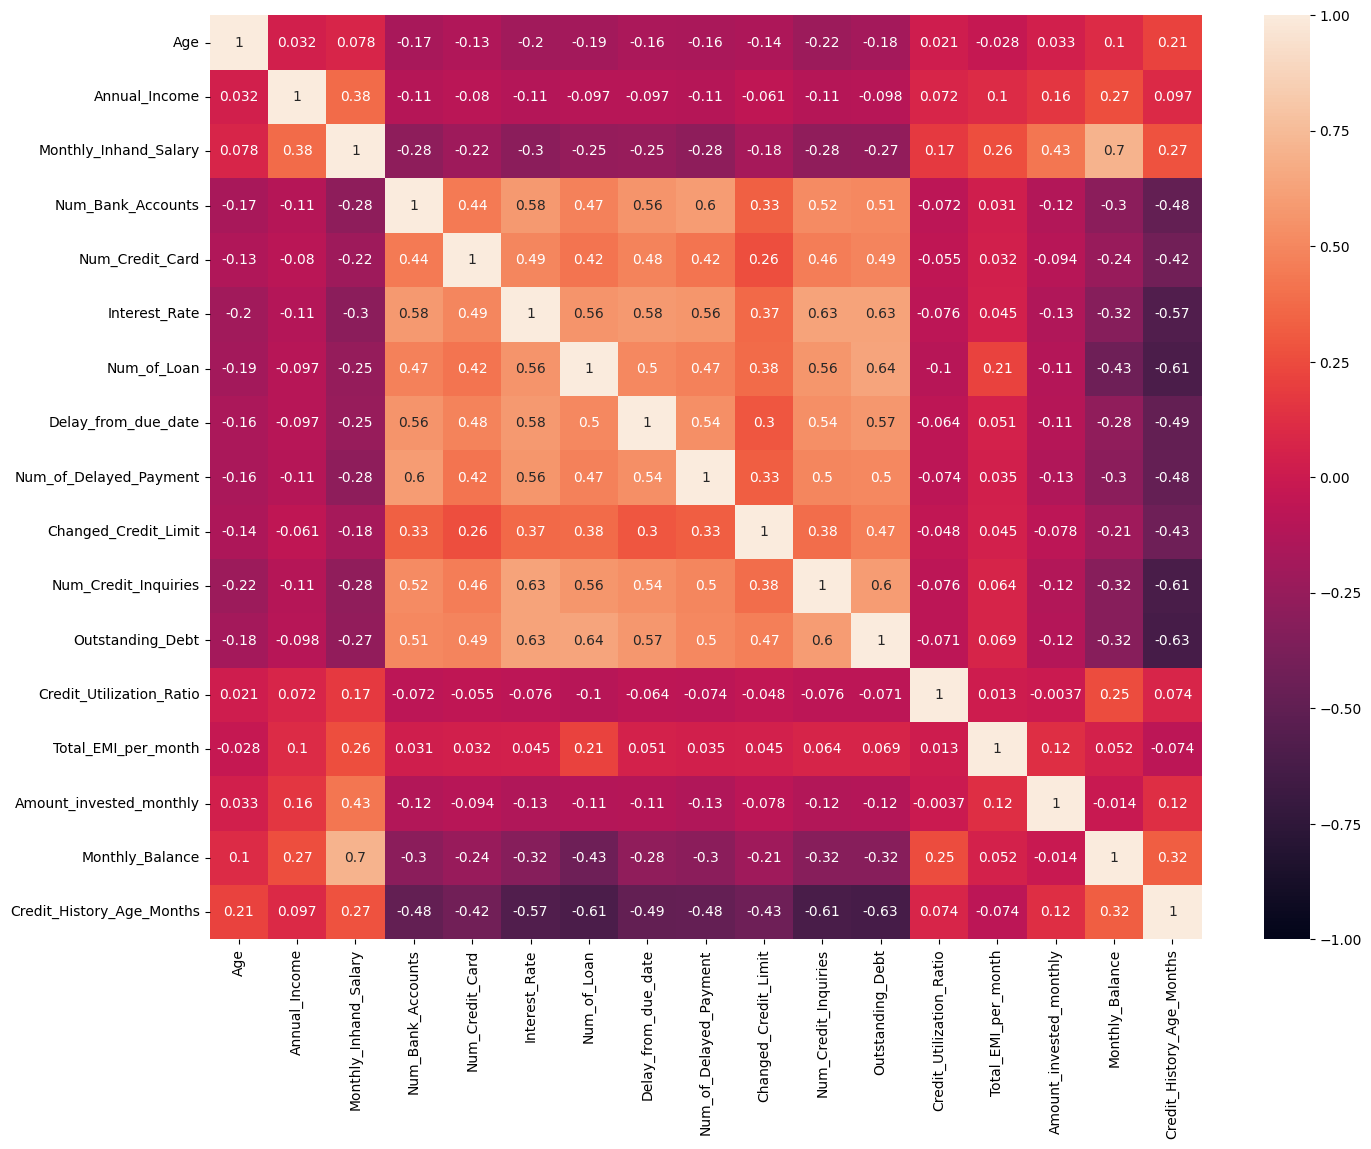

In [57]:
import seaborn as sns


num_columns = df.select_dtypes(include=np.number)

corr_matrix = num_columns.corr()
plt.figure(figsize=(16, 12))

heatmap = sns.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=1,
    annot=True
    )

plt.show()

In [58]:
df_corr = corr_matrix.unstack().reset_index()
df_corr.columns = ["Feature_1", "Feature_2", "Correlation"]

high_corr = df_corr[
    (df_corr["Feature_1"] < df_corr["Feature_2"])
    & (df_corr["Correlation"].abs() >= 0.5)
].sort_values(by="Correlation", ascending=False, key=abs)

high_corr

,Feature_1,Feature_2,Correlation
257,Monthly_Balance,Monthly_Inhand_Salary,0.704704
113,Num_of_Loan,Outstanding_Debt,0.639301
283,Credit_History_Age_Months,Outstanding_Debt,-0.629217
95,Interest_Rate,Num_Credit_Inquiries,0.628510
96,Interest_Rate,Outstanding_Debt,0.625031
282,Credit_History_Age_Months,Num_Credit_Inquiries,-0.610521
278,Credit_History_Age_Months,Num_of_Loan,-0.607207
59,Num_Bank_Accounts,Num_of_Delayed_Payment,0.597710
181,Num_Credit_Inquiries,Outstanding_Debt,0.597619
124,Delay_from_due_date,Interest_Rate,0.582503


In [59]:
columns_log_transform = ["Annual_Income", "Monthly_Inhand_Salary", "Total_EMI_per_month", "Amount_invested_monthly", "Monthly_Balance"]

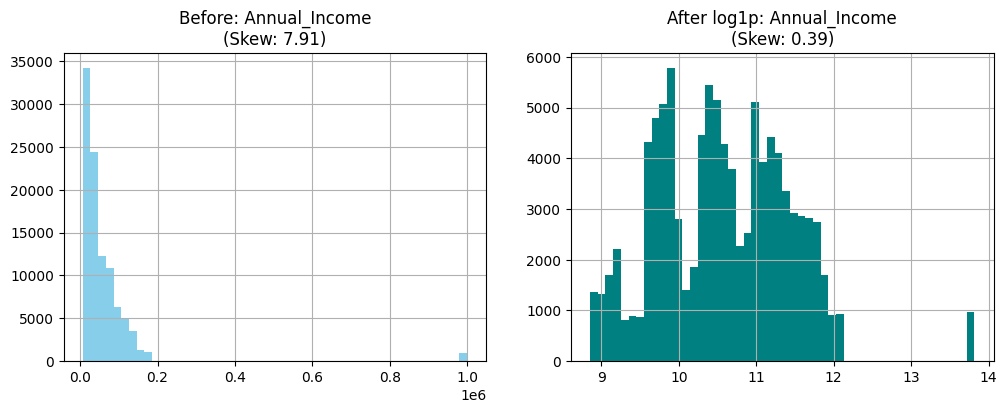

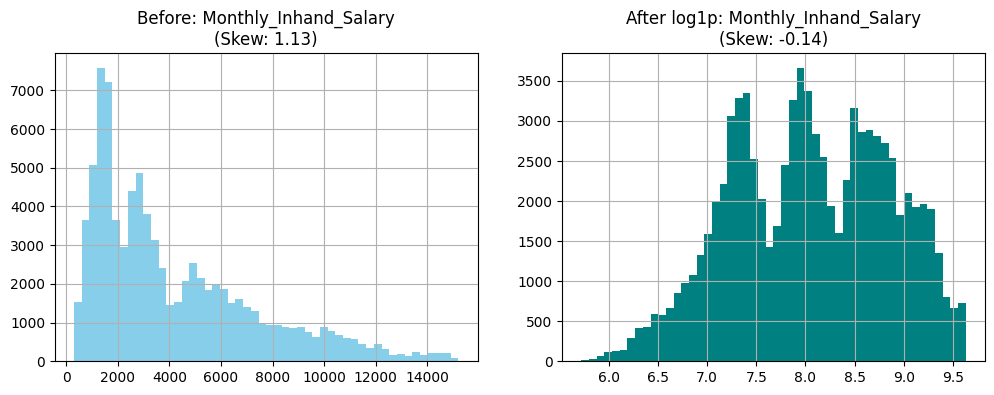

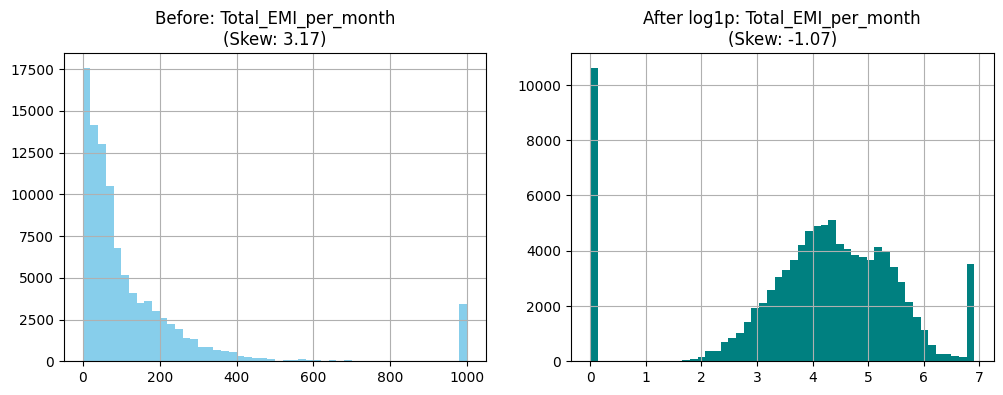

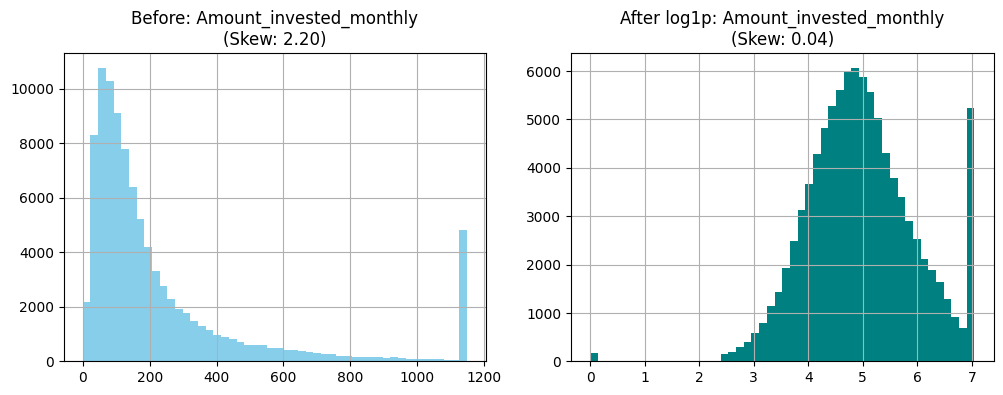

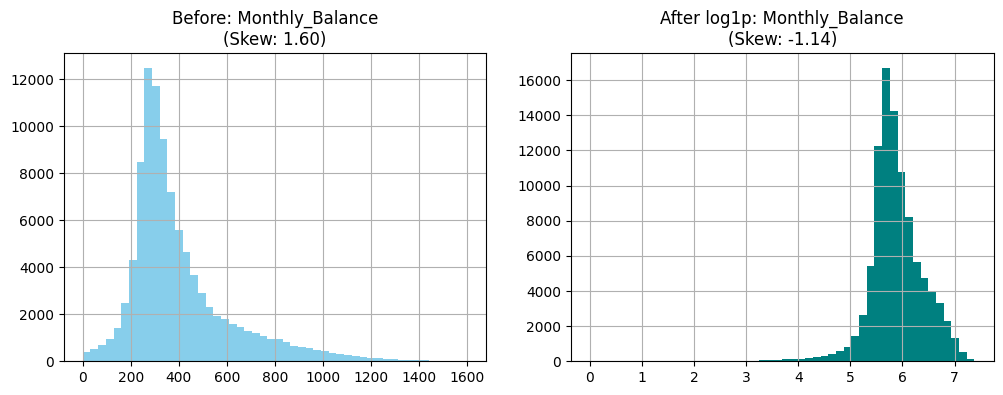

In [60]:
for col in columns_log_transform:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    df[col].hist(bins=50, color="skyblue")
    plt.title(f"Before: {col}\n(Skew: {df[col].skew():.2f})")

    plt.subplot(1, 2, 2)
    np.log1p(df[col]).hist(bins=50, color="teal")
    plt.title(f"After log1p: {col}\n(Skew: {np.log1p(df[col]).skew():.2f})")

    plt.show()

In [61]:
df[columns_log_transform] = np.log1p(df[columns_log_transform])

##Categorical values

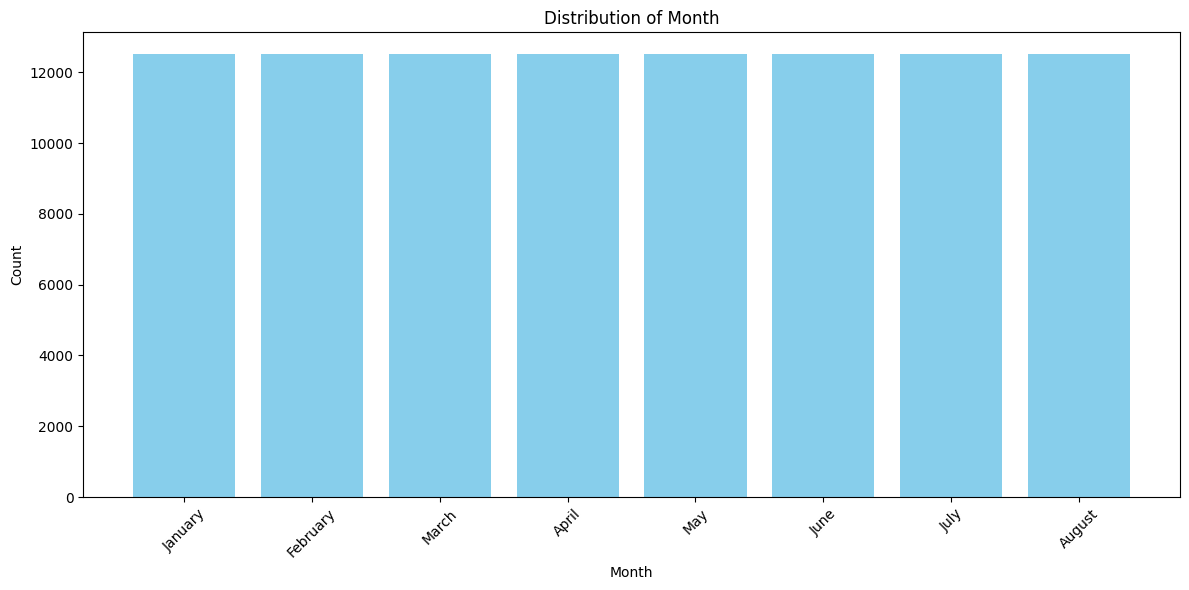

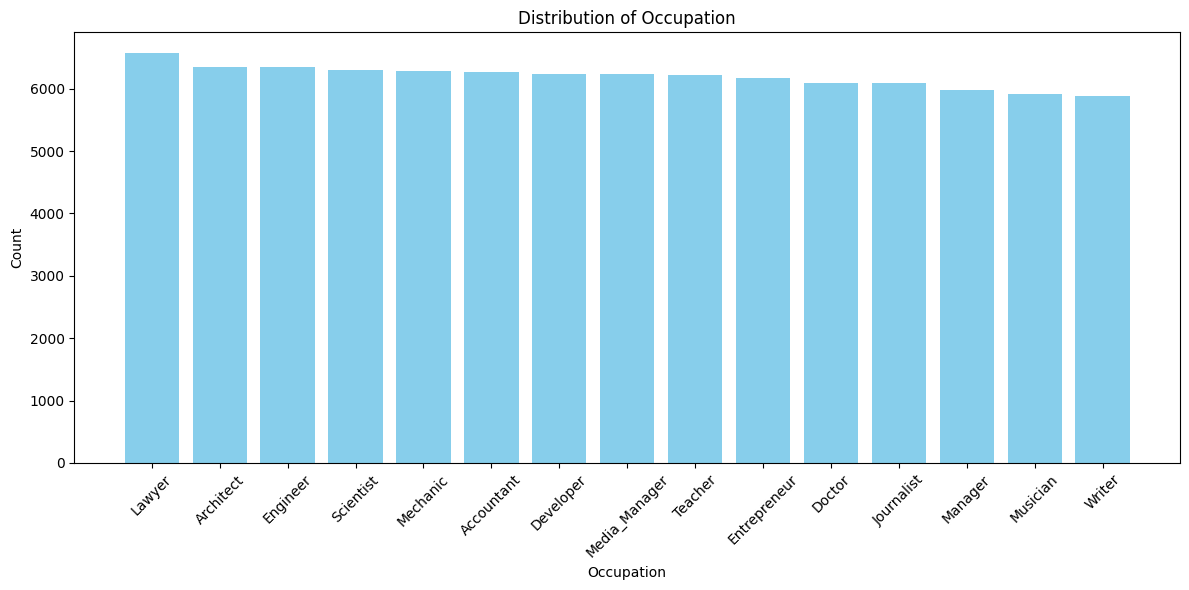

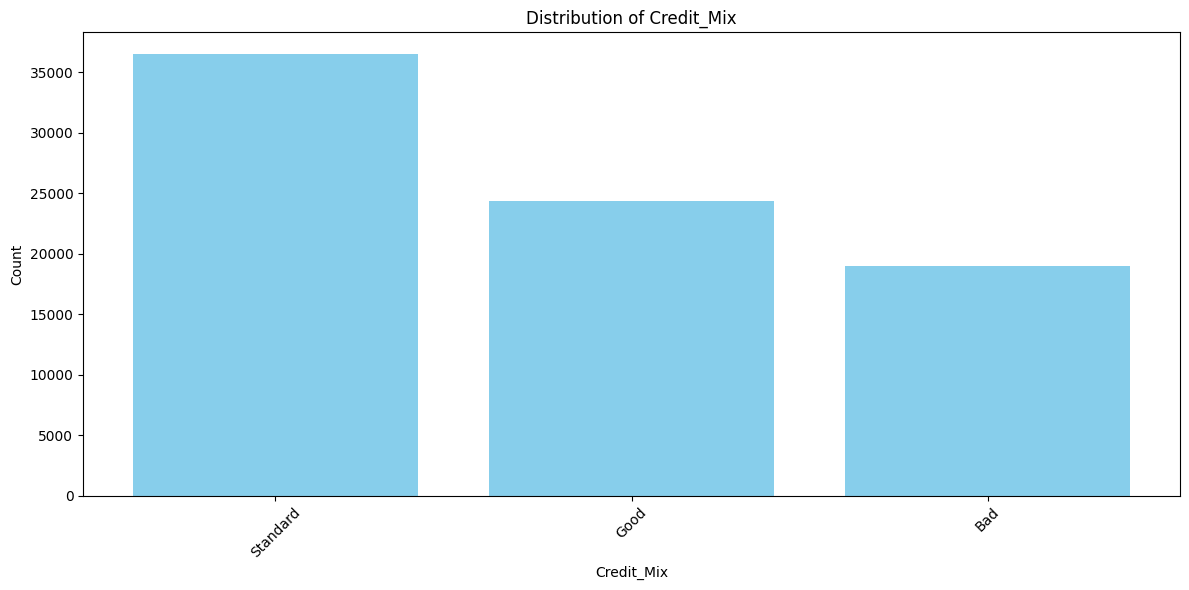

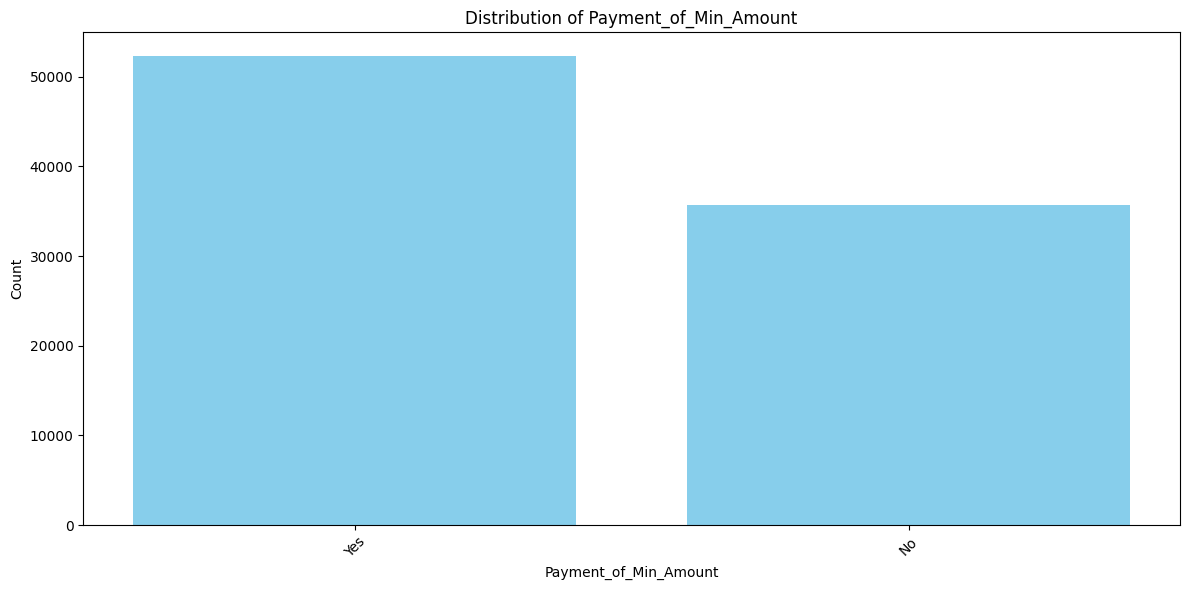

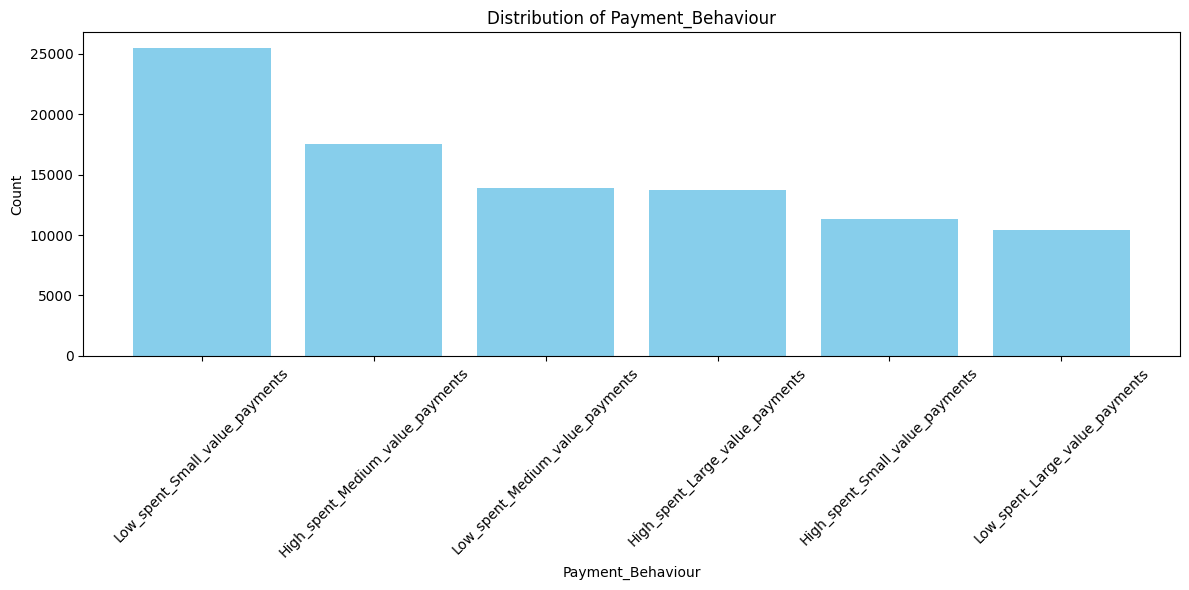

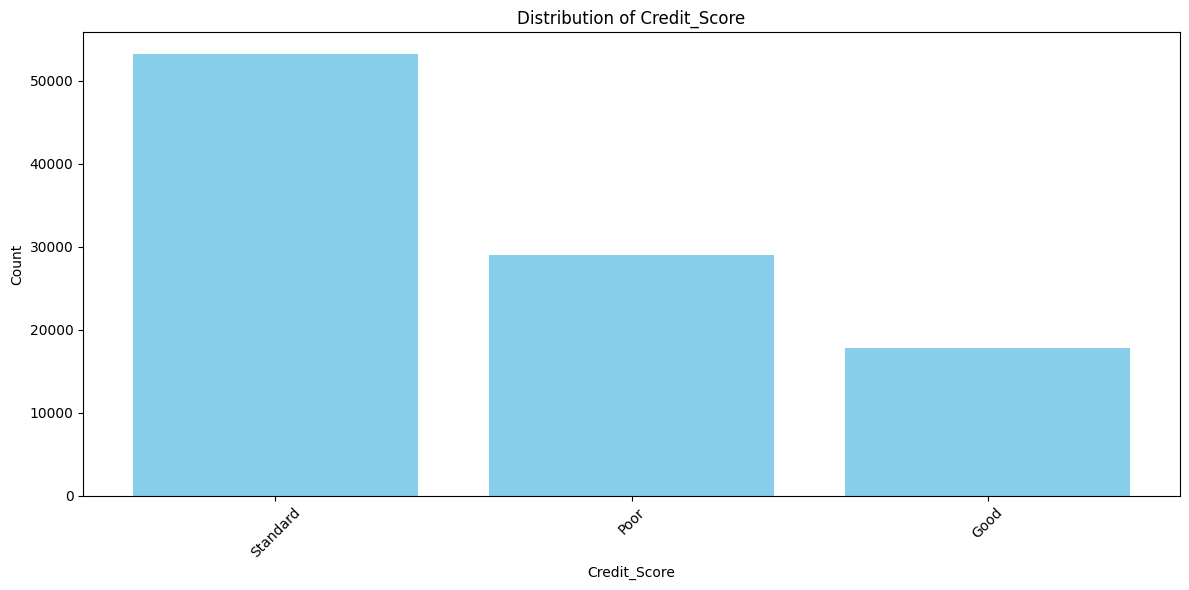

In [62]:
categorical_columns = df.select_dtypes(include="object")

for col in categorical_columns:
    plt.figure(figsize=(12, 6))

    counts = df[col].value_counts()

    plt.bar(counts.index, counts.values, color="skyblue")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

The dataset exhibits moderate class imbalance. The majority class (Standard) is roughly 3 times larger than the minority class (Good).

In [63]:
score_map = {"Poor": 0, "Standard": 1, "Good": 2}
df["Credit_Score"] = df["Credit_Score"].map(score_map)

# Feature Engineering

In [64]:
df['DTI_Ratio'] = df['Outstanding_Debt'] / (df['Monthly_Inhand_Salary'] + 1e-5)

In [65]:
df['EMI_to_Income_Ratio'] = df['Total_EMI_per_month'] / (df['Monthly_Inhand_Salary'] + 1e-5)

In [66]:
df['Savings_Ratio'] = df['Monthly_Balance'] / (df['Monthly_Inhand_Salary'] + 1e-5)

# Pipeline

In [67]:
X = df.drop(['Credit_Score'], axis=1)
y = df['Credit_Score'].copy()

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [69]:
cat_features = X_train.select_dtypes(exclude=[np.number]).columns
num_features = X_train.select_dtypes(include=[np.number]).columns

In [70]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [71]:
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])

transformer = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
], remainder="passthrough")

In [72]:
def model_pipeline(model):
    return Pipeline([
        ('preprocessing', transformer),
        ('estimator', model)
    ])

##Logistic Regression Model

In [73]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_pipeline = model_pipeline(lr_model)

In [74]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'N...
       'Credit_History_Age_Months', 'DTI_Ratio', 'EMI_to_Income_Ratio',
       'Savings_Ratio'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object'))])),
                ('estimator', LogisticRegression())])

In [75]:
print(f'Train score: {lr_pipeline.score(X_train, y_train)}\nTest score: {lr_pipeline.score(X_test, y_test)}')

Train score: 0.6499875
Test score: 0.65135


## Decision Tree

In [76]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier()

tree_pipeline = model_pipeline(tree_model)

In [77]:
tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'N...
       'Credit_History_Age_Months', 'DTI_Ratio', 'EMI_to_Income_Ratio',
       'Savings_Ratio'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object'))])),
                ('estimator', DecisionTreeClassifier())])

In [78]:
print(f'Train score: {tree_pipeline.score(X_train, y_train)}\nTest score: {tree_pipeline.score(X_test, y_test)}')

Train score: 1.0
Test score: 0.68925


## Random Forest

In [79]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(n_jobs=-1)

forest_pipeline = model_pipeline(forest_model)

In [80]:
forest_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'N...
       'Credit_History_Age_Months', 'DTI_Ratio', 'EMI_to_Income_Ratio',
       'Savings_Ratio'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object'))])),
                ('estimator', RandomForestClassifier(n_jobs=-1))])

In [81]:
print(f'Train score: {forest_pipeline.score(X_train, y_train)}\nTest score: {forest_pipeline.score(X_test, y_test)}')

Train score: 1.0
Test score: 0.77685


# HyperTuning

In [82]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

In [89]:
param_dist = {
    "estimator__max_depth": randint(10, 16),
    "estimator__min_samples_leaf": randint(5, 15),
    "estimator__min_samples_split": randint(10, 30),
    "estimator__max_features": ["sqrt", "log2"],
    "estimator__n_estimators": randint(80, 150),
}

random_search_forest = RandomizedSearchCV(
    estimator=forest_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

In [90]:
random_search_forest.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('num',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(add_indicator=True,
                                                                                                              strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num...
                                        'estimator__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e80db1930b0>,
                                        'estimator__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e80daf43240>,
                                        'estimator__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e80daf43020>},
                   random_state=42, scoring='f1_macro', verbose=2)

In [91]:
from sklearn.base import clone

original_best = random_search_forest.best_estimator_

scaled_best = clone(original_best)
scaled_best.named_steps["estimator"].set_params(n_estimators=300)
scaled_best.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'N...
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount',
       'Payment_Behaviour'],
      dtype='object'))])),
                ('estimator',
                 RandomForestClassifier(max_depth=15, min_samples_leaf=13,
                                        min_samples_split=26, n_estimators=300,
                                        n_jobs=-1))])

In [92]:
orig_train = original_best.score(X_train, y_train)
orig_test = original_best.score(X_test, y_test)

In [93]:
scaled_train = scaled_best.score(X_train, y_train)
scaled_test = scaled_best.score(X_test, y_test)

In [94]:
print("--- MODEL COMPARISON ---")
print(
    f"Original Search Model ({original_best.named_steps['estimator'].n_estimators} trees):"
)
print(
    f"  Train Acc: {orig_train:.4f} | Test Acc: {orig_test:.4f} | Gap: {orig_train - orig_test:.4f}"
)

print(f"\nScaled-Up Model (300 trees):")
print(
    f"  Train Acc: {scaled_train:.4f} | Test Acc: {scaled_test:.4f} | Gap: {scaled_train - scaled_test:.4f}"
)

--- MODEL COMPARISON ---
Original Search Model (138 trees):
  Train Acc: 0.7725 | Test Acc: 0.7273 | Gap: 0.0452

Scaled-Up Model (300 trees):
  Train Acc: 0.7722 | Test Acc: 0.7285 | Gap: 0.0437


##XGBoost

In [98]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = model_pipeline(xgb_model)

xgb_pipeline.fit(X_train, y_train)

train_acc = xgb_pipeline.score(X_train, y_train)
test_acc = xgb_pipeline.score(X_test, y_test)

print(f"XGBoost Train Accuracy: {train_acc:.4f}")
print(f"XGBoost Test Accuracy:  {test_acc:.4f}")
print(f"Overfitting Gap:        {train_acc - test_acc:.4f}")

XGBoost Train Accuracy: 0.7787
XGBoost Test Accuracy:  0.7387
Overfitting Gap:        0.0400


# Metrics

##Random Forest

In [111]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_test_rfc = original_best.predict(X_test)

In [114]:
print("        ----- TEST SET METRICS - Random Forest -----\n")
print(classification_report(y_test, y_pred_test_rfc))

        ----- TEST SET METRICS - Random Forest -----

              precision    recall  f1-score   support

           0       0.76      0.68      0.72      5799
           1       0.77      0.76      0.76     10635
           2       0.59      0.71      0.65      3566

    accuracy                           0.73     20000
   macro avg       0.71      0.72      0.71     20000
weighted avg       0.73      0.73      0.73     20000



##XGBoost

In [115]:
y_pred_test_xgb = xgb_pipeline.predict(X_test)

In [117]:
print("             ----- TEST SET METRICS - XGBoost -----\n")
print(classification_report(y_test, y_pred_test_xgb))

             ----- TEST SET METRICS - XGBoost -----

              precision    recall  f1-score   support

           0       0.76      0.69      0.72      5799
           1       0.76      0.78      0.77     10635
           2       0.64      0.68      0.66      3566

    accuracy                           0.74     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.74      0.74      0.74     20000

